# Diabetes Risk Prediction — Data Loading & EDA

**Goal:** Understand the CDC Diabetes Health Indicators dataset before modeling.

Sections:
1. Load data
2. Basic checks (shape, types, missing values, duplicates)
3. Target variable / class balance
4. Feature distributions
5. Feature relationships with target
6. Key takeaways

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.Collecting xgboost



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 5.1.5 requires pyqt5<5.13, which is not installed.
spyder 5.1.5 requires pyqtwebengine<5.13, which is not installed.


  Attempting uninstall: pygments
    Found existing installation: Pygments 2.10.0
    Uninstalling Pygments-2.10.0:
      Successfully uninstalled Pygments-2.10.0
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.10.0.2
    Uninstalling typing-extensions-3.10.0.2:
      Successfully uninstalled typing-extensions-3.10.0.2


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load Data

Option A: use the `ucimlrepo` package (recommended, handles versioning for you).
Option B: download the CSV directly if `ucimlrepo` gives you trouble.

In [2]:
from ucimlrepo import fetch_ucirepo

cdc_diabetes = fetch_ucirepo(id=891)

X = cdc_diabetes.data.features
y = cdc_diabetes.data.targets

df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [3]:
print(cdc_diabetes.variables)

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

## 2. Basic Checks

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

In [5]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values per column:
HighBP       0
HighChol     0
Income       0
Education    0
Age          0
Sex          0
DiffWalk     0
PhysHlth     0
MentHlth     0
GenHlth      0
dtype: int64


In [6]:
# Duplicate rows — known issue with this dataset
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes} ({n_dupes / len(df):.1%} of data)')

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after dropping duplicates: {df_clean.shape}')

Duplicate rows: 24206 (9.5% of data)
Shape after dropping duplicates: (229474, 22)


## 3. Target Variable / Class Balance

0    194377
1     35097
Name: Diabetes_binary, dtype: int64
0    84.7
1    15.3
Name: Diabetes_binary, dtype: float64


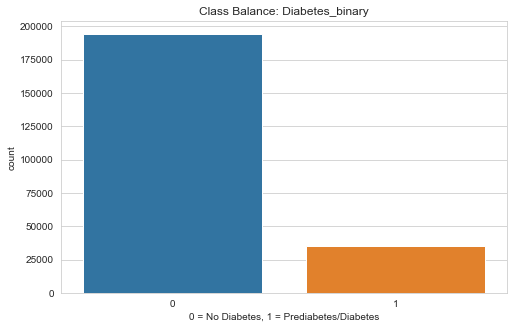

In [7]:
target_col = 'Diabetes_binary'

counts = df_clean[target_col].value_counts()
pct = df_clean[target_col].value_counts(normalize=True) * 100

print(counts)
print(pct.round(1))

sns.countplot(x=target_col, data=df_clean)
plt.title('Class Balance: Diabetes_binary')
plt.xlabel('0 = No Diabetes, 1 = Prediabetes/Diabetes')
plt.show()

## 4. Feature Distributions

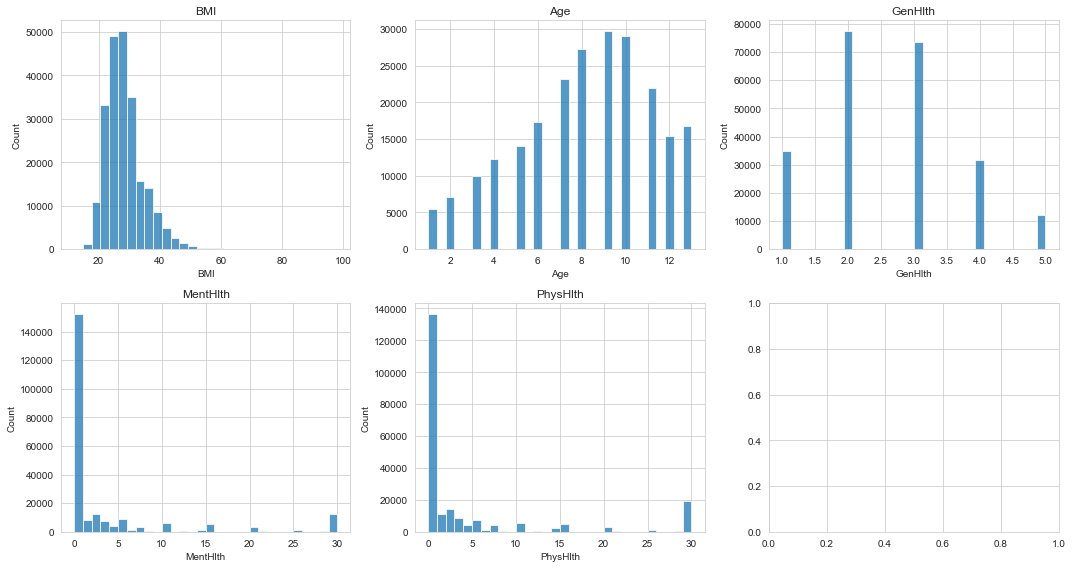

In [8]:
features_to_plot = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    if col in df_clean.columns:
        sns.histplot(df_clean[col], bins=30, ax=axes[i])
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

## 5. Feature Relationships with Target

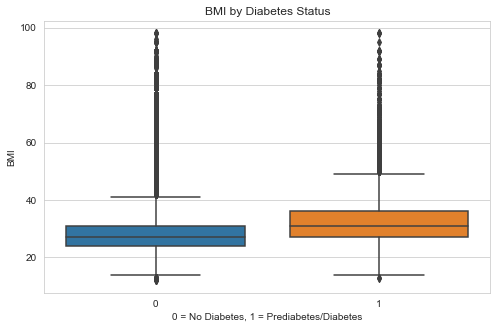

In [9]:
# Example: BMI by diabetes status
sns.boxplot(x=target_col, y='BMI', data=df_clean)
plt.title('BMI by Diabetes Status')
plt.xlabel('0 = No Diabetes, 1 = Prediabetes/Diabetes')
plt.show()

In [10]:
# Correlation of all features with the target (quick way to scan for strong signals)
corr_with_target = df_clean.corr(numeric_only=True)[target_col].sort_values(ascending=False)
print(corr_with_target)

TypeError: corr() got an unexpected keyword argument 'numeric_only'

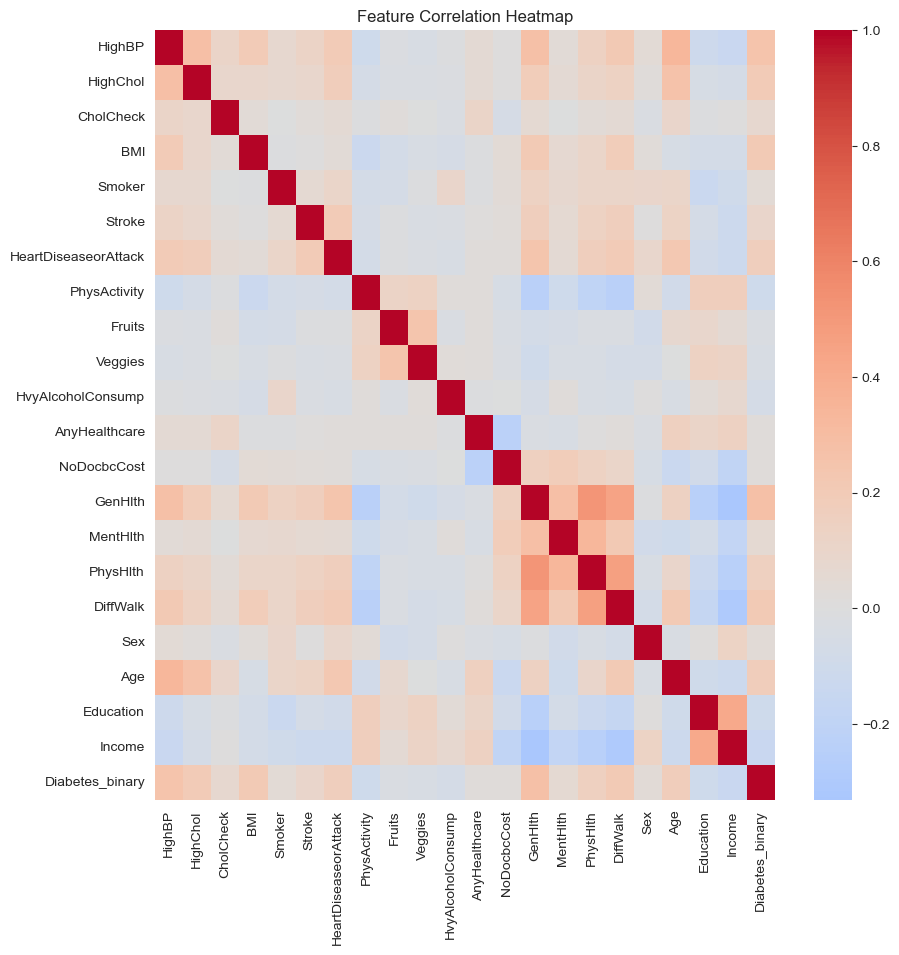

In [24]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()